In [1]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

## Load configs and forward model

Read configuration and collect the data 

In [2]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

Load the forward model 

In [3]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Read old and new data

In [4]:
adata_loop1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/adata_500k_residual.h5ad")
adata_loop2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k_residual.h5ad")

adata_loop2.obs["cell_type"] = "Unannotated"
adata_loop2p5.obs["cell_type"] = "Unannotated"

In [6]:
sc.tl.pca(adata_loop2)
sc.pp.neighbors(adata_loop2)
sc.tl.umap(adata_loop2)

sc.tl.pca(adata_loop2p5)
sc.pp.neighbors(adata_loop2p5)
sc.tl.umap(adata_loop2p5)

## Annotate cells based on markers 

In [7]:
adata_loop1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_loop2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")

adata_loop2.obs["cell_type"] = "Unannotated"

In [ ]:
for marker in adata_loop2.var.index:
    sc.pl.umap(adata_loop2, s=20, color=marker)

for marker in adata_loop2p5.var.index:
    sc.pl.umap(adata_loop2p5, s=20, color=marker)

In [ ]:
for exp in adata_loop2.obs.experiment_number.unique():
    sc.pl.umap(adata_loop2, s=20, color="experiment_number", groups=exp)

for exp in adata_loop2p5.obs.experiment_number.unique():
    sc.pl.umap(adata_loop2p5, s=20, color="experiment_number", groups=exp)

# Annotate cells based on markers 

In [8]:
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

(dict_keys(['mean', 'std']), dict_keys(['mean', 'std']))

In [9]:
adata_loop1.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_loop1.obs.columns
]

adata_loop2.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_loop2.obs.columns
]

adata_loop2p5.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_loop2p5.obs.columns
]

In [10]:
X_channel_loop2 = adata_loop2.X
X_channel_loop2p5 = adata_loop2p5.X

# The model 
X_channel_loop2 = (X_channel_loop2 - channel_params["mean"])/channel_params["std"]
X_channel_loop2p5 = (X_channel_loop2p5 - channel_params["mean"])/channel_params["std"]

X_scatter_loop2 = []
X_scatter_loop2p5 = []
for col in config.annotation.scatter_columns:
    col_vals_loop2 = adata_loop2.obs[col].astype(float).values
    col_vals_loop2p5 = adata_loop2p5.obs[col].astype(float).values
    X_scatter_loop2.append(col_vals_loop2)
    X_scatter_loop2p5.append(col_vals_loop2p5)
    
X_scatter_loop2 = np.stack(X_scatter_loop2, axis=1)
X_scatter_loop2 = (X_scatter_loop2 - scatter_params["mean"])/scatter_params["std"]
X_scatter_loop2p5 = np.stack(X_scatter_loop2p5, axis=1)
X_scatter_loop2p5 = (X_scatter_loop2p5 - scatter_params["mean"])/scatter_params["std"]


X_loop2 = np.concatenate(
    (
        X_channel_loop2, X_scatter_loop2
    ), axis=1
)

X_loop2p5 = np.concatenate(
    (
        X_channel_loop2p5, X_scatter_loop2p5
    ), axis=1
)

print(f"{X_channel_loop2.shape=} {X_scatter_loop2.shape=}")
print(f"{X_channel_loop2p5.shape=} {X_scatter_loop2p5.shape=}")

X_channel_loop2.shape=(499995, 20) X_scatter_loop2.shape=(499995, 6)
X_channel_loop2p5.shape=(500000, 20) X_scatter_loop2p5.shape=(500000, 6)


In [ ]:
dataloader_loop2 = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_loop2)), 
    batch_size=4026,
    shuffle=False
)

dataloader_loop2p5 = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_loop2p5)), 
    batch_size=4026,
    shuffle=False
)


ct_predictions_loop2 = []
ct_predictions_loop2p5 = []

with torch.no_grad():
    for batch in tqdm(dataloader_loop2):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions_loop2.append(y_pred.cpu().detach().numpy())
ct_predictions_loop2 = np.concatenate(ct_predictions_loop2)

with torch.no_grad():
    for batch in tqdm(dataloader_loop2p5):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions_loop2p5.append(y_pred.cpu().detach().numpy())
ct_predictions_loop2p5 = np.concatenate(ct_predictions_loop2p5)

In [ ]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [ ]:
ct_predictions_str_loop2 = classes[ct_predictions_loop2]
ct_predictions_str_loop2p5 = classes[ct_predictions_loop2p5]

In [ ]:
adata_loop2.obs["cell_type"] = ct_predictions_str_loop2
adata_loop2p5.obs["cell_type"] = ct_predictions_str_loop2p5

In [ ]:
adata_loop2.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_loop2p5.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")

## Refine marker based annotation

In [12]:
adata_loop2_plots = adata_loop2.copy()
adata_loop2p5_plots = adata_loop2p5.copy()

In [14]:
# color_map = {
#     'HSCs': '#003049',
#     'earlyMPP': '#023e8a',
#     'MPP': '#005f73',
#     'GMP-Neutro': '#0a9396',
#     'GMP_cycling': '#1d3557',
#     'MPP_MgkEry': '#264653',
#     'MgKEryPro1': '#7f908f',
#     'MgKEryPro2': '#4a5c6a',
#     'MgkPro': '#3a4f6a',
#     'EosBasMast1': '#6c757d',
#     'EosBasMast2': '#780000',
#     'EosBasMast3': '#9d0910',
#     'EryPro': '#af0e18',
#     'MLP': '#c1121f',
#     'LMPP-CLP': '#ae2012',
#     'preProB': '#9b2226',
#     'ProB': '#df817a',
#     'Pre-DC1': '#e76f51',
#     'Pre-DC2': '#f4a261',
#     'Early_GMP': '#ee9b00',
#     'CD14Mono': '#fdf0d5',
#     'CD16Mono': '#e9d8a6',
#     'CyclingPro1': '#669bbc',
#     'CyclingPro2': '#8ecae6',
# }

# rename_map = {
#     "late_MgkPro": "MgkPro",
#     "pre_cDC1": "Pre-DC1",
#     "pre_cDC2": "Pre-DC2",
# }

# # Rename cell types
# adata_loop2_plots.obs['cell_type'] = adata_loop2_plots.obs['cell_type'].replace(rename_map)
# adata_loop2p5_plots.obs['cell_type'] = adata_loop2p5_plots.obs['cell_type'].replace(rename_map)

# # Build ordered palette matching the cell types present in adata
# cell_types = adata_loop2_plots.obs['cell_type'].cat.categories.tolist()
# palette = [color_map.get(ct, '#cccccc') for ct in cell_types]

# sc.pl.umap(adata_loop2_plots, color="cell_type", s=20, palette=palette)
# sc.pl.umap(adata_loop2p5_plots, color="cell_type", s=20, palette=palette)

In [ ]:
sc.pl.umap(adata_loop2p5_plots, color="cell_type", groups="EryPro", s=40)

## Check enrichments

In [15]:
adata_combined = sc.concat([adata_loop2_plots,adata_loop2p5_plots])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [16]:
adata_combined.obs["cell_type"] = adata_combined.obs["cell_type"].astype("category")

In [17]:
protocols_loop2 = adata_combined.obs.loc[:, protocol_cols + ["experiment_number"]] 
protocols_loop2 = protocols_loop2.astype(float)

In [18]:
unique_protocols = pd.DataFrame(np.unique(protocols_loop2, axis=0))
unique_protocols.columns = protocols_loop2.columns

unique_protocols = unique_protocols.set_index("experiment_number")
unique_protocols["enriched_ct"] = None

In [24]:
unique_protocols.loc[239, "enriched_ct"] = "late_mgkPro_low_u"
unique_protocols.loc[240, "enriched_ct"] = "late_mgkPro_high_u0"
unique_protocols.loc[248, "enriched_ct"] = "late_mgkPro_high_u1"

unique_protocols.loc[241, "enriched_ct"] = "EryPro_low_u"
unique_protocols.loc[242, "enriched_ct"] = "EryPro_high_u0"
unique_protocols.loc[249, "enriched_ct"] = "EryPro_high_u1"

unique_protocols.loc[243, "enriched_ct"] = "HSC_low_u"
unique_protocols.loc[244, "enriched_ct"] = "HSC_high_u1"
unique_protocols.loc[250, "enriched_ct"] = "HSC_high_u2"

unique_protocols.loc[245, "enriched_ct"] = "preProB_high_u0"
unique_protocols.loc[246, "enriched_ct"] = "preProB_low_u1"
unique_protocols.loc[251, "enriched_ct"] = "preProB_high_u2"

In [25]:
unique_protocols

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,enriched_ct
experiment_number,,,,,,,,,,,,,
239.0,0.00,0.00,0.00,66.54,0.0,0.00,110.51,0.00,0.0,0.0,20.0,14.0,late_mgkPro_low_u
240.0,5.94,0.44,12.45,0.00,0.0,47.13,5.03,1.27,0.0,0.0,10.0,14.0,late_mgkPro_high_u0
248.0,6.83,0.55,21.97,0.26,0.0,50.36,5.63,1.21,0.0,0.0,10.0,14.0,late_mgkPro_high_u1
243.0,7.10,3.40,579.20,1479.70,0.0,58.90,0.00,0.40,50.0,0.0,20.0,14.0,HSC_low_u
246.0,8.60,2.40,927.90,735.60,0.2,57.70,0.00,0.00,0.0,0.0,20.0,14.0,preProB_low_u1
250.0,8.70,2.50,754.30,1080.60,0.0,50.80,0.00,0.20,0.0,14.8,13.5,14.0,HSC_high_u2
244.0,8.70,2.50,755.20,1064.10,0.0,51.00,0.00,0.30,0.0,14.2,13.5,14.0,HSC_high_u1
242.0,9.10,2.20,173.50,0.20,0.0,3.20,0.00,0.00,0.0,0.0,10.0,14.0,EryPro_high_u0
245.0,9.20,2.20,997.30,1120.20,0.0,57.20,0.00,0.00,0.1,0.6,20.0,14.0,preProB_high_u0


In [26]:
map_prot_to_ct = dict(zip(unique_protocols.index, unique_protocols.enriched_ct))

In [27]:
map_prot_to_ct

{239.0: 'late_mgkPro_low_u',
 240.0: 'late_mgkPro_high_u0',
 248.0: 'late_mgkPro_high_u1',
 243.0: 'HSC_low_u',
 246.0: 'preProB_low_u1',
 250.0: 'HSC_high_u2',
 244.0: 'HSC_high_u1',
 242.0: 'EryPro_high_u0',
 245.0: 'preProB_high_u0',
 247.0: None,
 251.0: 'preProB_high_u2',
 249.0: 'EryPro_high_u1',
 241.0: 'EryPro_low_u'}

In [28]:
annot_combined = [map_prot_to_ct[float(exp_number)] for exp_number in  adata_combined.obs.experiment_number]

adata_combined.obs["Experiment_type"] = annot_combined

## Plot 

In [29]:
exp_number_ct_prop = {}

In [ ]:
for exp_no in np.unique(adata_combined.obs.experiment_number):
    adata_exp = adata_combined[adata_combined.obs.experiment_number==exp_no]
    ct_prop = adata_exp.obs.cell_type.value_counts()
    for ct in classes:
        if ct not in ct_prop.index:
            ct_prop[ct] = 0
    exp_number_ct_prop[exp_no] = ct_prop

In [ ]:
for exp_no in exp_number_ct_prop:
    
    data = exp_number_ct_prop[exp_no]
    # convert to proportions
    prop = data / data.sum()
    
    # Rename cell types
    prop.index = prop.index.map(lambda x: rename_map.get(x, x))
    
    # Keep only top 12 cell types by proportion
    prop = prop.nlargest(12)
    
    # Map colors to the cell types present in this experiment
    colors = [color_map.get(ct, '#cccccc') for ct in prop.index]
    
    fig, ax = plt.subplots(figsize=(5,3))
    sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel("Proportion")
    ax.set_title(f"Experiment {exp_no} / exp type {map_prot_to_ct[float(exp_no)]}")
    plt.tight_layout()
    
    # Save as SVG in .plots folder
    filename = f"experiment_{exp_no}_ct_proportions.svg"
    fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

# Concatenate anndata

In [31]:
import anndata as ad

adata_combined = ad.concat(
    [adata_loop1, adata_combined])
adata_combined.obs["experiment_number"] = adata_combined.obs["experiment_number"].astype(str)
adata_combined.obs["count_beads"] = adata_combined.obs["count_beads"].astype(str)
adata_combined.obs["cell_counts"] = adata_combined.obs["count_beads"].astype(int)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


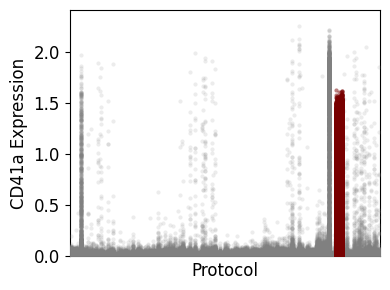

In [32]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD41a'] = adata_combined[:, 'CD41a'].X.toarray().flatten()
to_exclude = ["241", "242", "243", "244", "245", "246", "247", "249", "250", "251", "252"]
to_highlight = ["239", "240", "248"]
# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]
# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)
# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)
fig, ax = plt.subplots(figsize=(4, 3))
sns.stripplot(
    data=plot_df[plot_df["group"] == "other"],
    x="experiment_number",
    y="CD41a",
    color="gray",
    alpha=0.15,
    size=3,
    dodge=False,
    ax=ax
)
sns.stripplot(
    data=plot_df[plot_df["group"] == "highlight"],
    x="experiment_number",
    y="CD41a",
    color="#780000",
    alpha=0.5,
    size=3,
    dodge=False,
    ax=ax
)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD41a Expression", fontsize=12)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(
    "CD41a_vs_others.png",
    format='png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()
plt.close(fig)

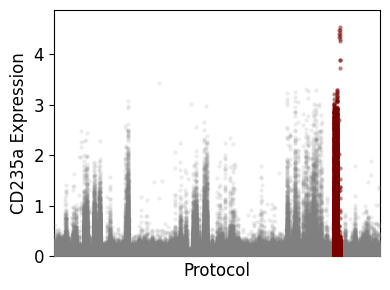

In [33]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD235a'] = adata_combined[:, 'CD235a'].X.toarray().flatten()
to_exclude = ["239", "240", "243", "244", "245", "246", "247", "248", "250", "251"]
to_highlight = ["241", "242", "249"]
# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]
# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)
# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)
fig, ax = plt.subplots(figsize=(4, 3))
sns.stripplot(
    data=plot_df[plot_df["group"] == "other"],
    x="experiment_number",
    y="CD235a",
    color="gray",
    alpha=0.15,
    size=3,
    dodge=False,
    ax=ax
)
sns.stripplot(
    data=plot_df[plot_df["group"] == "highlight"],
    x="experiment_number",
    y="CD235a",
    color="#780000",
    alpha=0.5,
    size=3,
    dodge=False,
    ax=ax
)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD235a Expression", fontsize=12)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(
    "CD235a_vs_others.png",
    format='png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()
plt.close(fig)

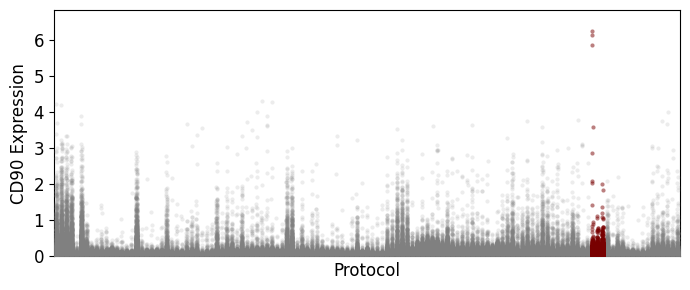

In [63]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD90'] = adata_combined[:, 'CD90'].X.toarray().flatten()
to_exclude = ["239", "240", "248", "241", "242", "249", "245", "246", "247",  "251"]
to_highlight = ["243", "244", "250"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]
# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)
# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)
fig, ax = plt.subplots(figsize=(7, 3))
sns.stripplot(
    data=plot_df[plot_df["group"] == "other"],
    x="experiment_number",
    y="CD90",
    color="gray",
    alpha=0.15,
    size=3,
    dodge=False,
    ax=ax
)
sns.stripplot(
    data=plot_df[plot_df["group"] == "highlight"],
    x="experiment_number",
    y="CD90",
    color="#780000",
    alpha=0.5,
    size=3,
    dodge=False,
    ax=ax
)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD90 Expression", fontsize=12)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(
    "CD90_vs_others.png",
    format='png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()
plt.close(fig)

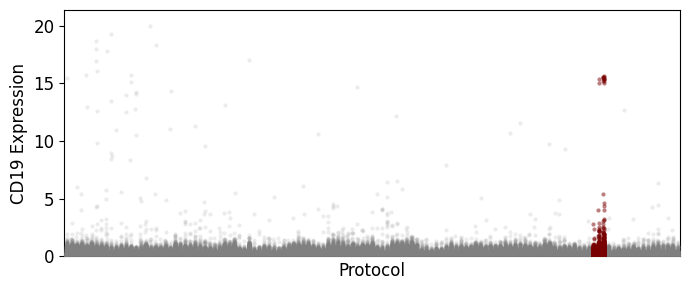

In [62]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD19'] = adata_combined[:, 'CD19'].X.toarray().flatten()
to_exclude = ["239", "240", "248", "241", "242", "249", "243", "244", "247", "250"]
to_highlight = ["245", "246", "251"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]
# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)
# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)
fig, ax = plt.subplots(figsize=(7, 3))
sns.stripplot(
    data=plot_df[plot_df["group"] == "other"],
    x="experiment_number",
    y="CD19",
    color="gray",
    alpha=0.15,
    size=3,
    dodge=False,
    ax=ax
)
sns.stripplot(
    data=plot_df[plot_df["group"] == "highlight"],
    x="experiment_number",
    y="CD19",
    color="#780000",
    alpha=0.5,
    size=3,
    dodge=False,
    ax=ax
)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD19 Expression", fontsize=12)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(
    "CD19_vs_others.png",
    format='png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()
plt.close(fig)

## Check experiment number with highest prop. of EryPro

In [37]:
adata_500k = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop0/adata_500k.h5ad")

In [38]:
exp = 0
ery_p = 0
for exp in np.unique(adata_500k.obs.experiment_number):
    adata_500k_exp = adata_500k[adata_500k.obs["experiment_number"]==exp]
    erypro_prop = (adata_500k_exp.obs["cell_type"]=="EryPro").sum() / adata_500k_exp.shape[0]
    if erypro_prop>ery_p:
        ery_p = erypro_prop
        exp = exp

## Concat UMAP

In [39]:
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_loop2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")

In [40]:
adata_concat = sc.concat([adata_loop2, adata_loop2p5])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
sc.pp.subsample(adata_concat, 0.33)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
sc.tl.pca(adata_concat)
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)

In [ ]:
sc.pl.umap(adata_concat, s=20, color="cell_type", groups=["EryPro", "late_MgkPro"], palette=palette)

In [ ]:
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'late_MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

In [ ]:
palette = [color_map.get(ct, '#cccccc') for ct in ["EryPro", "late_MgkPro"]]